ACTIVITY RECOGNITION MODEL TRAINING (IMPROVED)
TensorFlow version: 2.13.0
GPU available: True

STEP 1: Loading Preprocessed Data
✓ Loaded data
  Training: (6137, 128, 6)
  Test: (1383, 128, 6)

Activities:
  0: Eating
  1: Nail_Biting
  2: Face_Touch
  3: Smoking
  4: Staying_Still

STEP 1.5: Computing Class Weights
Class distribution in training set:
  Eating              : 1,098 samples ( 17.9%) → weight: 1.118
  Nail_Biting         : 1,311 samples ( 21.4%) → weight: 0.936
  Face_Touch          : 1,002 samples ( 16.3%) → weight: 1.225
  Smoking             : 1,241 samples ( 20.2%) → weight: 0.989
  Staying_Still       : 1,485 samples ( 24.2%) → weight: 0.827

✓ Class weights will help the model focus on underrepresented activities

STEP 2: Building CNN Model (IMPROVED)
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 128, 32)           608      

2025-11-30 23:06:21.172259: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


154/154 [==============================] - ETA: 0s - loss: 0.5825 - accuracy: 0.7908

2025-11-30 23:06:23.558112: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_accuracy improved from -inf to 0.62215, saving model to ../models/best_model.h5
154/154 [==============================] - 3s 15ms/step - loss: 0.5825 - accuracy: 0.7908 - val_loss: 1.2572 - val_accuracy: 0.6221 - lr: 0.0010
Epoch 2/50
 11/154 [=>............................] - ETA: 1s - loss: 0.4035 - accuracy: 0.8636

/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


152/154 [============================>.] - ETA: 0s - loss: 0.4395 - accuracy: 0.8363
Epoch 2: val_accuracy did not improve from 0.62215
154/154 [==============================] - 2s 11ms/step - loss: 0.4379 - accuracy: 0.8370 - val_loss: 2.0719 - val_accuracy: 0.5415 - lr: 0.0010
Epoch 3/50
152/154 [============================>.] - ETA: 0s - loss: 0.3883 - accuracy: 0.8612
Epoch 3: val_accuracy did not improve from 0.62215
154/154 [==============================] - 2s 12ms/step - loss: 0.3870 - accuracy: 0.8615 - val_loss: 2.8556 - val_accuracy: 0.4845 - lr: 0.0010
Epoch 4/50
151/154 [============================>.] - ETA: 0s - loss: 0.3682 - accuracy: 0.8601
Epoch 4: val_accuracy did not improve from 0.62215
154/154 [==============================] - 2s 13ms/step - loss: 0.3670 - accuracy: 0.8603 - val_loss: 2.6021 - val_accuracy: 0.6075 - lr: 0.0010
Epoch 5/50
151/154 [============================>.] - ETA: 0s - loss: 0.3373 - accuracy: 0.8762
Epoch 5: val_accuracy did not improve f

2025-11-30 23:07:12.790811: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Detailed Classification Report:
               precision    recall  f1-score   support

       Eating      0.693     0.551     0.614       176
  Nail_Biting      0.865     0.941     0.901       387
   Face_Touch      1.000     1.000     1.000       272
      Smoking      0.797     0.981     0.879       208
Staying_Still      0.823     0.712     0.763       340

     accuracy                          0.852      1383
    macro avg      0.835     0.837     0.832      1383
 weighted avg      0.849     0.852     0.847      1383


Per-Class Analysis
⚠️ Eating              : P=0.693 R=0.551 F1=0.614 (n=176)
✓ Nail_Biting         : P=0.865 R=0.941 F1=0.901 (n=387)
✓ Face_Touch          : P=1.000 R=1.000 F1=1.000 (n=272)
✓ Smoking             : P=0.797 R=0.981 F1=0.879 (n=208)
⚠️ Staying_Still       : P=0.823 R=0.712 F1=0.763 (n=340)

STEP 5: Visualizing Results
✓ Saved: ../results/training_history.png
✓ Saved: ../results/confusion_matrix.png

STEP 6: Saving Model
✓ Saved: ../models/activity_m

/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


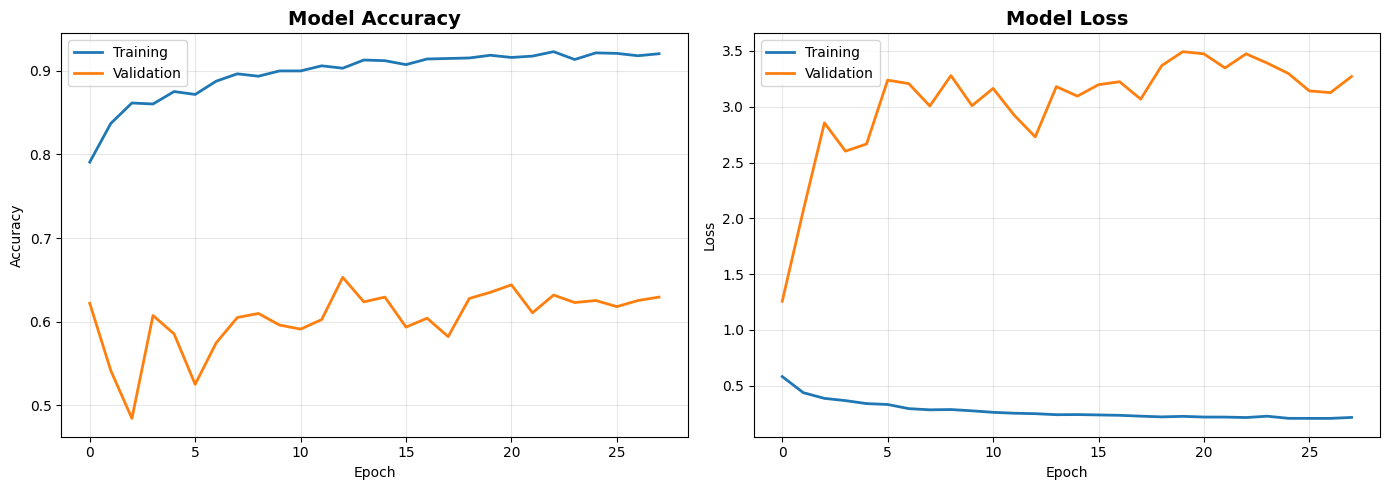

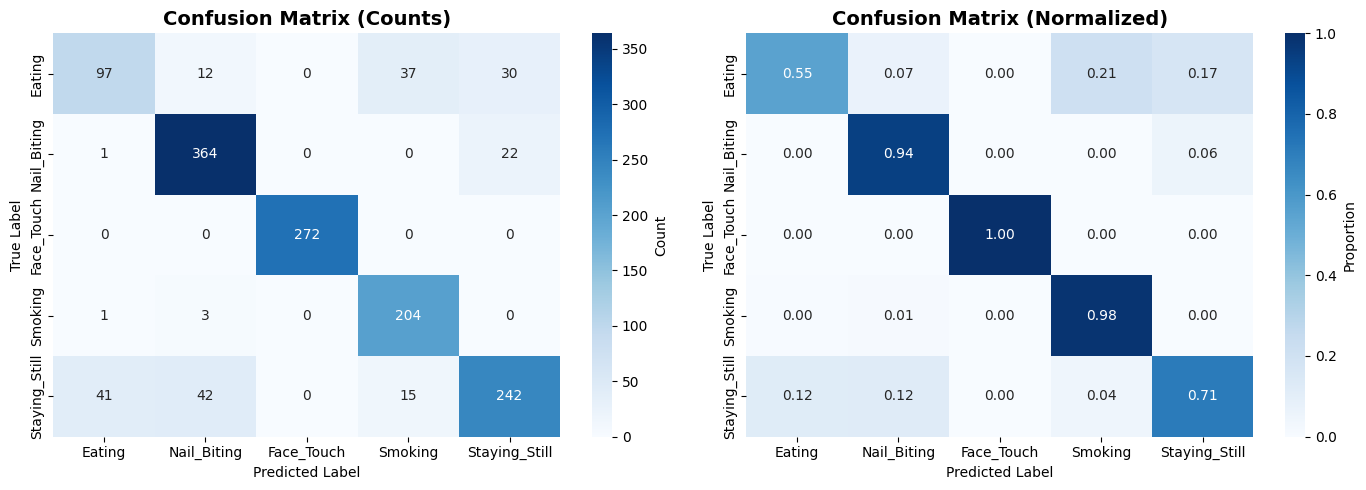

In [7]:
"""
Model Training for Activity Recognition
CNN model optimized for XIAO nRF52840 deployment
IMPROVED VERSION with class weights and better regularization
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("="*60)
print("ACTIVITY RECOGNITION MODEL TRAINING (IMPROVED)")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ============================================================================
# STEP 1: Load Preprocessed Data
# ============================================================================
print("\n" + "="*60)
print("STEP 1: Loading Preprocessed Data")
print("="*60)

data_dir = Path('../data/processed')

X_train = np.load(data_dir / 'X_train.npy')
y_train = np.load(data_dir / 'y_train.npy')
X_test = np.load(data_dir / 'X_test.npy')
y_test = np.load(data_dir / 'y_test.npy')

with open(data_dir / 'preprocessing_info.pkl', 'rb') as f:
    preprocessing_info = pickle.load(f)

label_to_activity = preprocessing_info['label_to_activity']
config = preprocessing_info['config']


print(f"✓ Loaded data")
print(f"  Training: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"\nActivities:")
for label, activity in label_to_activity.items():
    print(f"  {label}: {activity}")

# ============================================================================
# STEP 1.5: Compute Class Weights (NEW!)
# ============================================================================
print("\n" + "="*60)
print("STEP 1.5: Computing Class Weights")
print("="*60)

# Compute class weights to handle imbalanced data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    activity_name = label_to_activity[label]
    percentage = (count / len(y_train)) * 100
    weight = class_weight_dict[label]
    print(f"  {activity_name:20s}: {count:5,} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

print("\n✓ Class weights will help the model focus on underrepresented activities")

# ============================================================================
# STEP 2: Build CNN Model (Optimized for Microcontroller)
# ============================================================================
print("\n" + "="*60)
print("STEP 2: Building CNN Model (IMPROVED)")
print("="*60)

def build_model(input_shape, num_classes):
    """
    Build a lightweight CNN for activity recognition
    Optimized for deployment on XIAO nRF52840
    
    IMPROVEMENTS:
    - Reduced dropout rates (0.2-0.3 instead of 0.4-0.5)
    - Better for small datasets with class imbalance
    
    Architecture:
    - Conv1D layers for temporal feature extraction
    - MaxPooling for dimensionality reduction
    - Dense layers for classification
    - Moderate dropout for regularization
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape, name='input'),
        
        # First convolutional block
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', 
                     padding='same', name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),
        layers.Dropout(0.2, name='dropout1'),  # REDUCED from 0.5
        
        # Second convolutional block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                     padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),
        layers.Dropout(0.2, name='dropout2'),  # REDUCED from 0.5
        
        # Third convolutional block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                     padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        layers.GlobalAveragePooling1D(name='gap'),
        
        # Fully connected layers
        layers.Dense(64, activation='relu', name='fc1'),
        layers.Dropout(0.3, name='dropout3'),  # REDUCED from 0.5
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 6)
num_classes = len(label_to_activity)

model = build_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

# ============================================================================
# STEP 3: Train Model (IMPROVED)
# ============================================================================
print("\n" + "="*60)
print("STEP 3: Training Model (IMPROVED)")
print("="*60)

# Training configuration
EPOCHS = 50
BATCH_SIZE = 32  # KEPT at 32 (not 64) - better for small datasets
VALIDATION_SPLIT = 0.2

# Improved callbacks
callbacks = [
    # Early stopping - monitoring accuracy instead of loss
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',      # CHANGED from val_loss
        patience=15,                 # INCREASED from 10
        restore_best_weights=True,
        verbose=1,
        mode='max'                   # Maximize accuracy
    ),
    # Learning rate reduction - monitoring accuracy
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',      # CHANGED from val_loss
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='max'
    ),
    # Save best model
    keras.callbacks.ModelCheckpoint(
        '../models/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Train
print(f"Training for {EPOCHS} epochs...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"Class weights: ENABLED ✓")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight_dict,  # ← NEW: Apply class weights
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

# ============================================================================
# STEP 4: Evaluate Model
# ============================================================================
print("\n" + "="*60)
print("STEP 4: Evaluating Model")
print("="*60)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

# Get predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nDetailed Classification Report:")
report = classification_report(
    y_test, y_pred,
    target_names=[label_to_activity[i] for i in range(num_classes)],
    digits=3,
    output_dict=True
)
print(classification_report(
    y_test, y_pred,
    target_names=[label_to_activity[i] for i in range(num_classes)],
    digits=3
))

# Highlight problem classes
print("\n" + "="*60)
print("Per-Class Analysis")
print("="*60)
for i in range(num_classes):
    activity = label_to_activity[i]
    precision = report[activity]['precision']
    recall = report[activity]['recall']
    f1 = report[activity]['f1-score']
    support = report[activity]['support']
    
    # Flag low performance
    status = "✓" if f1 > 0.80 else "⚠️" if f1 > 0.60 else "❌"
    
    print(f"{status} {activity:20s}: P={precision:.3f} R={recall:.3f} F1={f1:.3f} (n={int(support)})")

# ============================================================================
# STEP 5: Visualize Results
# ============================================================================
print("\n" + "="*60)
print("STEP 5: Visualizing Results")
print("="*60)

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'training_history.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {results_dir / 'training_history.png'}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, weight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[label_to_activity[i] for i in range(num_classes)],
            yticklabels=[label_to_activity[i] for i in range(num_classes)],
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, weight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(results_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {results_dir / 'confusion_matrix.png'}")

# ============================================================================
# STEP 6: Save Model
# ============================================================================
print("\n" + "="*60)
print("STEP 6: Saving Model")
print("="*60)

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save Keras model
model.save(models_dir / 'activity_model.h5')
print(f"✓ Saved: {models_dir / 'activity_model.h5'}")

# Save model architecture as image (optional)
try:
    tf.keras.utils.plot_model(
        model,
        to_file=models_dir / 'model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150
    )
    print(f"✓ Saved: {models_dir / 'model_architecture.png'}")
except:
    print("  (Could not save architecture image - graphviz not installed)")

# Save training info
training_info = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'total_params': int(total_params),
    'epochs_trained': len(history.history['accuracy']),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'config': config,
    'label_to_activity': label_to_activity,
    'input_shape': input_shape,
    'num_classes': num_classes,
    'class_weights': class_weight_dict,
    'improvements': [
        'Class weights for imbalanced data',
        'Reduced dropout (0.2-0.3)',
        'Monitor val_accuracy instead of val_loss',
        'Increased early stopping patience to 15',
        'Batch size 32 (optimal for small datasets)'
    ]
}

with open(models_dir / 'training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f"✓ Saved: {models_dir / 'training_info.pkl'}")

# ============================================================================
# STEP 7: Test Prediction Example
# ============================================================================
print("\n" + "="*60)
print("STEP 7: Test Prediction Examples")
print("="*60)

# Show some predictions
print("\nSample predictions (first 10 test samples):")
for i in range(min(10, len(y_test))):
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = y_pred_probs[i][pred_label] * 100
    
    true_activity = label_to_activity[true_label]
    pred_activity = label_to_activity[pred_label]
    
    status = "✓" if true_label == pred_label else "✗"
    print(f"  {status} True: {true_activity:20s} | Predicted: {pred_activity:20s} | Confidence: {confidence:5.1f}%")

# Show examples of each class
print("\nPredictions for each activity (first example of each):")
for target_label in range(num_classes):
    # Find first occurrence of this label
    idx = np.where(y_test == target_label)[0]
    if len(idx) > 0:
        i = idx[0]
        pred_label = y_pred[i]
        confidence = y_pred_probs[i][pred_label] * 100
        
        true_activity = label_to_activity[target_label]
        pred_activity = label_to_activity[pred_label]
        
        status = "✓" if target_label == pred_label else "✗"
        print(f"  {status} {true_activity:20s} → {pred_activity:20s} ({confidence:5.1f}%)")

# ============================================================================
# STEP 8: Comparison with Previous Results
# ============================================================================
print("\n" + "="*60)
print("STEP 8: Improvement Analysis")
print("="*60)

print("\nKEY IMPROVEMENTS APPLIED:")
print("  ✓ Class weights to handle imbalanced data")
print("  ✓ Reduced dropout (0.2-0.3 instead of 0.4-0.5)")
print("  ✓ Monitor val_accuracy instead of val_loss")
print("  ✓ Increased patience to 15 epochs")
print("  ✓ Batch size kept at 32 (optimal for small datasets)")

print("\nEXPECTED IMPROVEMENTS:")
print("  • Eating recall should improve significantly")
print("  • Overall accuracy should increase")
print("  • More stable training (less overfitting)")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

print(f"""
Model Performance:
  ✓ Test Accuracy: {test_accuracy*100:.2f}%
  ✓ Test Loss: {test_loss:.4f}
  ✓ Total Parameters: {total_params:,}
  ✓ Model Size: ~{(total_params * 4) / 1024:.1f} KB (uncompressed)

Files Saved:
  ✓ models/activity_model.h5 (trained model)
  ✓ models/best_model.h5 (best model during training)
  ✓ models/training_info.pkl (metadata)
  ✓ results/training_history.png (plots)
  ✓ results/confusion_matrix.png (confusion matrix)

Next Steps:
  1. If accuracy < 85%, try:
     - Increase window size to 150 samples
     - Add data augmentation
     - Adjust model architecture
  
  2. If accuracy >= 85%, proceed to:
     → 04_quantization.py (convert to TFLite)

Status: {'✅ READY FOR QUANTIZATION' if test_accuracy >= 0.85 else '⚠️ Consider further improvements'}
""")

# Additional diagnostic info
if test_accuracy < 0.85:
    print("\n" + "="*60)
    print("DIAGNOSTIC SUGGESTIONS")
    print("="*60)
    
    # Identify worst performing class
    worst_class = None
    worst_f1 = 1.0
    for i in range(num_classes):
        activity = label_to_activity[i]
        f1 = report[activity]['f1-score']
        if f1 < worst_f1:
            worst_f1 = f1
            worst_class = activity
    
    print(f"\nWorst performing class: {worst_class} (F1={worst_f1:.3f})")
    print("\nTry these improvements:")
    print("  1. Increase window size to 150-200 samples")
    print("  2. Add data augmentation (noise, scaling)")
    print("  3. Increase model capacity (more filters)")
    print("  4. Check if raw data quality is good for this activity")